---
title: 'Derivations, Not Just Simulations'
subtitle: Teaching Applied Mathematics with Scientific Python
abstract: |
  Scientific computing in Python is fluent in two of David Tall's three
  worlds of mathematical learning: NumPy and SciPy handle operational
  symbolism; matplotlib and reactive notebooks handle conceptual
  embodiment. The third world, axiomatic formalism — where coordinate
  transformations, optimality criteria, and invariances live as
  symbol-manipulation under formal rules — typically stays on paper.
  SymPy is the SciPy-ecosystem tool that brings it into the same
  execution environment, and once all three worlds are executable in
  one notebook the glass-box principle (Buchberger; Drijvers; Artigue)
  becomes practicable for working scientists.

  The worked exemplar is Isaacs\'s 1951 homicidal-chauffeur differential
  game. *Naive heuristics catch the evader in 11.3 seconds; the
  saddle-point optimal play catches in 12.1 seconds, but its evader
  path has a sharp mid-chase kink no physical intuition predicts.* The
  body derives the optimal feedback symbolically, integrates it
  backward from the capture circle, and renders the value function as
  a heat map. The mathematics is canonical; what we claim is the
  executable implementation — Python modules shipped alongside the
  article, exercised by an automated test suite.
---


In [1]:
# Notebook setup — sp.init_printing makes SymPy cells auto-render as LaTeX.
import sympy as sp
sp.init_printing()


## The problem: teaching advanced applied math to working scientists

Scientific-computing users reach for the SciPy stack when they need numerical methods. This paper argues that the same stack — extended with MyST and a reactive notebook — also operationalises a thirty-year-old theory of how people learn mathematics. We make the case with one worked exemplar: the value function of a 1951 differential game.

The audience we have in mind is the engineer or scientist who reaches for `scipy.integrate.solve_ivp` and `numpy.linalg.eig` reflexively but treats symbolic derivations as something other people do on paper. David Tall [@tall2008transition] named exactly this reader: a *user* of mathematics who needs the mathematical objects working before they need the proofs that justify them. The SciPy stack already serves two of the three worlds Tall describes — *operational-symbolic* procedures (solving, integrating, optimising) and *conceptual-embodiment* (plots, interactive sliders) — but the *axiomatic-formal* world, where a symbol *is* the object and an equation is what you manipulate, usually lives in a textbook citation rather than an executable cell.

SymPy closes that gap. The central claim of this paper is that with SymPy in the notebook alongside NumPy/SciPy and matplotlib, the *glass-box principle* [@buchberger1990] (refined by Drijvers and Artigue [@artigue2002; @tall1991amtcomputer]) finally becomes practicable: the reader can read the seam between a derived expression, the function it lambdifies into, and the figure it renders — and verify the whole chain, rather than trust one opaque step. SymPy is what unlocks the third world for scientific-computing practice. Proprietary computer-algebra systems (Maple, Mathematica) and other open-source ones (Maxima, Sage) have offered symbolic capabilities for decades; the novel pivot here is having *all three Tall worlds executable in the same open-source Python kernel and notebook*, alongside the NumPy/SciPy/matplotlib idiom the working reader already uses.

We pick the homicidal chauffeur (HC) — Isaacs's 1951 differential game — as the worked exemplar because it has every component the argument needs: a clean derivation chain that benefits from symbolic manipulation, an analytical singular-surface structure that makes a striking visualisation, and small enough scope to fit in a 6,000-word notebook. The publication substrate itself (Jupyter, MyST, Curvenote [@kluyver2016jupyter; @jupyterbook2025]) is part of the demonstration; everything below this paragraph is executable.

Section 2 names the two pedagogical frameworks this paper depends on. Section 3 introduces the exemplar with the figure that poses the question the rest of the paper answers. Two threads run in parallel through what follows: an *implementation* (the executable derivation chain in `paper.ipynb` plus the modules and tests beside it) and an *argument* (the three-worlds executability category that the implementation grounds). Each load-bears on the other.


## Three worlds and three boxes

Two pedagogical frameworks structure the rest of the paper. Both come from the mathematics-education research literature, both were articulated in the late 1980s, and both translate cleanly into questions about scientific computing.

David Tall [@tall2008transition; @tall2013] describes mathematical cognition as three "worlds" of meaning, each with its own characteristic objects and modes of reasoning. The **conceptual-embodied world** is where mathematics is sensed and pictured: a vector field you can feel the divergence of, a trajectory you can trace with your eye, a slider you can scrub to watch a parameter change behaviour. The **proceptual-symbolic world** is where mathematics is a procedure you also treat as an object — Sfard's process-object duality, introduced by Sfard [@sfard1991] and elaborated by Tall as the *procept*: `f'(x)` is both a differentiation procedure you execute on `f` and an object you can integrate, compose, or compare. The **axiomatic-formal world** is where mathematics is symbol manipulation under formally defined rules: `f` *is* an element of a function space, `f'` *is* the linear operator the derivation rules give you, and a "proof" is a tree of formal rewrites. Each world is a legitimate way of doing mathematics; mature practitioners move between them constantly without naming the moves.

Bruno Buchberger [@buchberger1990] gave a complementary principle, articulated at the 1989 RISC computer-algebra colloquium: when teaching a method, learners need a **white-box** phase where they execute every step by hand to understand how the method works, before they can responsibly use a **black-box** tool that wraps the method. Heid [@heid1988] had observed the same pattern empirically: when a computer algebra system (CAS) removes the symbolic-manipulation burden, students still need supervised practice with the structure underneath. Buchberger's principle is *spiral*: today's white-box is tomorrow's black-box, freeing tomorrow's white-box to be something more abstract. Differentiation and integration rules have been in their black-box phase since Heid's 1988 studies, which is what releases this paper's white-box phase to be about Hamiltonian construction and costate derivation rather than chain rules.

Drijvers and Artigue [@artigue2002; @tall1991amtcomputer] sharpened the Buchberger binary into a third mode: **glass-box**, where the tool is transparent in *derivation* even when the user did not perform every algebraic step by hand. A glass-box workflow lets the reader inspect each intermediate object the tool produced, ask why each step is justified, and re-run any step with different inputs. The distinction between white-box and glass-box matters for this paper: we do not hand-execute every algebraic step (that would be white-box), but every step we ask SymPy to perform is *inspectable* (glass-box). Section 7 will earn the term with a worked example; the rest of the paper trades on it.


## The case study: the homicidal chauffeur (lens, not subject)

The homicidal chauffeur — introduced by Rufus Isaacs in a 1951 RAND memorandum [@isaacs1951] and developed in his 1965 textbook [@isaacs1965] — is a two-player differential game. A pursuer moves at constant unit speed but turns under a bounded angular rate (the "chauffeur": fast forward, sluggish to turn); an evader moves at constant speed `w<1` in any direction it chooses (the "pedestrian": slow, agile). The pursuer wants to capture the evader as quickly as possible by closing within a fixed distance `ℓ`; the evader wants to delay capture as long as possible. Merz [@merz1971] gave the complete singular-surface taxonomy that makes optimal play tractable; Pachter and Coates [@pachter2019hc] is the most-cited modern restatement; Patsko, Botkin, and Kein [@patsko2011hc] is the modern history and source for the live demos this paper draws on.

The first figure (`chase_demo`) shows one complete optimal chase. Read it from the **● circles** (initial positions): the blue pursuer behind and to the right of the red evader, both at rest at `t=0`. They evolve forward in time along the solid blue and dashed red curves until the **■ squares** at the moment of capture. The evader's path has a sharp **★** — the *dispersal kink* — about halfway through. We use the same visual vocabulary in every figure (all rendered via matplotlib [@hunter2007matplotlib]): circles start, squares end, stars mark events. Warm colours code positive switching-function values, cool colours code negative; the convention is documented in `plots.py` and walked through inline as each figure appears.

That ★ is the question the rest of the paper answers. The second figure (`naive_vs_optimal`) compares two heuristic evaders against the same heuristic pursuer at the same initial condition: a "run straight away from the pursuer" evader (left, captured at 11.3 seconds) and a "run perpendicular to the closing direction" evader (right, captured at 6.2 seconds). The saddle-point evader plays differently — captured at 12.1 seconds, with the ★ kink. The saddle-point theorem says no heuristic evader can do better than the optimal strategy against an optimal pursuer; the 12.1 seconds value is a *bound*, not a behavioural guess. **The question:** where does the ★ come from? Why does the evader's optimal path kink at that specific point? Sections 4 through 8 derive the answer; §3 is the puzzle the rest of the paper earns.


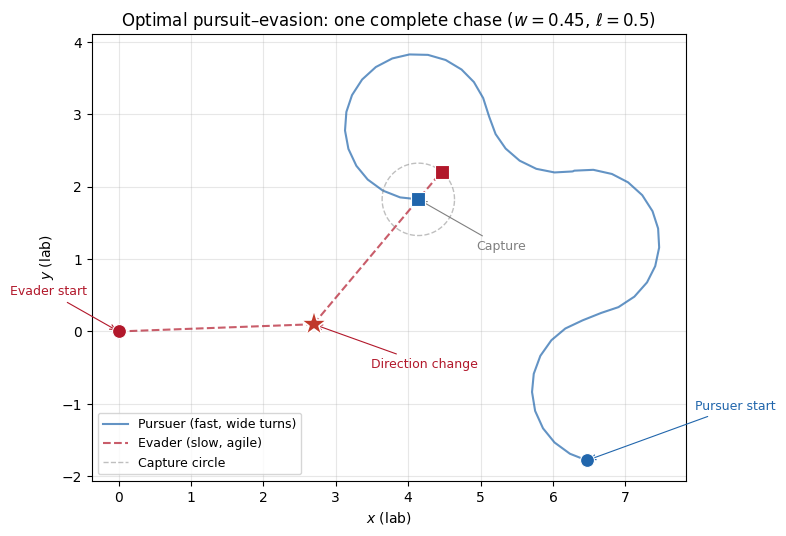

In [2]:
# §3 motivation figure — lifted from hc-marimo (real chase, dispersal crossing)
from plots import chase_demo
chase_demo()


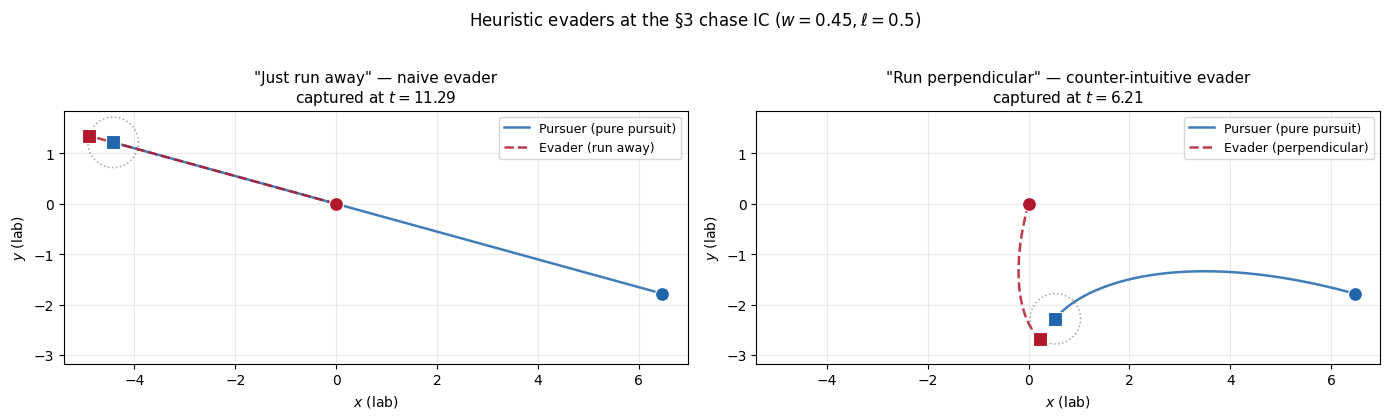

In [3]:
# §3 hook — two heuristic evaders at the chase_demo IC.
# See §3 prose for the saddle-point bound interpretation.
from plots import naive_vs_optimal
naive_vs_optimal()


## A crash course in *differential game* and *calculus of variations*

Calculus of variations and optimal control are load-bearing tools across applied mathematics — used routinely in aerospace, robotics, control engineering, mathematical biology, economics, and quantitative finance, though rarely taught outside narrow specializations at the undergraduate level. We chose a differential game rather than a single-player optimal-control problem because pursuit-evasion is essentially the children's game of *tag*: every reader has embodied experience of chasing and being chased, and that intuition is a place to hang the formalism on.

Two concepts from optimal control are load-bearing for the derivations that follow. We sketch them in one paragraph each. The Notation quickstart below carries the symbols; Appendix A holds the full glossary.

A **differential game** is the optimal-control generalisation of a saddle-point problem to continuous time. Two players control inputs `u_P` and `u_E` that jointly determine the state's evolution `ẋ = f(x, u_P, u_E)`. They have opposed objectives — one minimises a running cost `L(x, u_P, u_E)`, the other maximises it — and we look for a *saddle point* `(u_P*, u_E*)` where neither player can improve unilaterally. Isaacs's 1951 contribution was to formulate HC this way and to show that saddle points exist for many adversarial pursuit scenarios; the existence question is the hard part, and the answer depends on the singular-surface structure §7 visits.

The **Pontryagin maximum principle** (PMP) is the calculus-of-variations machinery that locates the saddle point. It introduces a costate vector `p(t)` (the same dimension as the state) and a Hamiltonian `H(x, p, u_P, u_E) = p · f + L`. The optimal controls minimise (resp. maximise) `H` over their feasible sets, and the state-costate pair evolves under Hamilton's equations `ẋ = ∂H/∂p`, `ṗ = -∂H/∂x`. For HC the Hamiltonian turns out to be linear in the pursuer control `φ`, which makes the optimal pursuer control "bang-bang" (always at the boundary of its feasible set, with sign chosen by a *switching function*). This linearity is the structural fact §6 exploits to derive the switching function in two SymPy calls.

The notation quickstart names the symbols this paper uses; each one is also defined at first technical use, and Appendix A holds the complete glossary including the body-frame dynamics and singular-surface vocabulary. With these handles in place, §5 turns to the HC-specific work: collapsing the 5-DOF lab-frame setup to the 2-DOF body-frame system every subsequent derivation operates on.


**Notation quickstart.**
Just the abstract objects of a Pontryagin / differential-game setup so the prose has handles to reach for. The HC-specific symbols ($x_1, x_2, \phi, \psi, \sigma, \ldots$) are introduced where they first appear in §5–§8; the full notation reference is **Appendix A** at the end.

| Term | Notation | Quickstart description |
|---|---|---|
| State vector | $\mathbf{x}$ | The system's evolving variables; in HC, the 2-DOF body-frame relative position |
| Player controls | $u_P,\ u_E$ | The two players' choices; in HC, pursuer turn rate $\phi$ and evader heading $\psi$ |
| Costate / adjoint | $\mathbf{p}$ | Pontryagin's adjoint vector; equals $\nabla V^*$, satisfies $\dot{\mathbf{p}} = -\partial H / \partial \mathbf{x}$ |
| Hamiltonian | $H(\mathbf{x}, \mathbf{p}, u_P, u_E)$ | The Pontryagin function; its gradient drives the state and costate ODEs |
| Value function | $V^*(\mathbf{x})$ | The saddle-point optimal cost from state $\mathbf{x}$; for HC, the optimal capture time |

That's the vocabulary §5–§8 will operationalise in SymPy. The reader does not need to memorise specific glyphs yet — they appear in cells with full context, and Appendix A is one click away.


## Reducing HC to body-frame coordinates (the symbolic-view warm-up)

The HC state is naturally described in the lab frame with five degrees of freedom: pursuer position `(x_P, y_P)` and heading `θ`, evader position `(x_E, y_E)`. The pursuer's kinematics are `ẋ_P = cos θ`, `ẏ_P = sin θ`, `θ̇ = φ` (with `|φ| ≤ 1` the normalised turn-rate control, `v_P = 1`, and minimum turning radius `R_min = 1`). The evader's kinematics are `ẋ_E = w cos ψ_lab`, `ẏ_E = w sin ψ_lab` where `ψ_lab` is the evader's lab-frame heading. Five DOF, two players, two controls — well-posed but ungainly.

But the *game* does not depend on five DOF. The same game is played by a pursuer at `(x_P, y_P)` heading north as by a pursuer at the origin heading north: only the *relative* position of the evader matters, and only relative to the pursuer's heading. Isaacs [@isaacs1965, pp. 297-300] gave the reduction: rotate and translate the lab frame so the pursuer sits at the origin facing the body-frame `+x_2` axis. The evader's heading relabels: `ψ ≡ ψ_lab − θ`, the angle the evader's velocity makes with the pursuer's heading.

The 5-DOF lab kinematics as a SymPy `Matrix`:


In [4]:
# §5 — Lab-frame absolute kinematics: the 5-DOF state
# (x_P, y_P, θ, x_E, y_E) and its time derivatives, normalised so v_P = 1
# and R_min = 1. This is what the body-frame reduction below collapses.
from derivations import absolute_kinematics
sp.Eq(
    sp.Matrix([
        sp.Symbol(r"\dot{x}_P"), sp.Symbol(r"\dot{y}_P"),
        sp.Symbol(r"\dot{\theta}"),
        sp.Symbol(r"\dot{x}_E"), sp.Symbol(r"\dot{y}_E"),
    ]),
    absolute_kinematics(),
)


⎡ \dot{x}_P  ⎤   ⎡          cos(θ)          ⎤
⎢            ⎥   ⎢                          ⎥
⎢ \dot{y}_P  ⎥   ⎢          sin(θ)          ⎥
⎢            ⎥   ⎢                          ⎥
⎢\dot{\theta}⎥ = ⎢            φ             ⎥
⎢            ⎥   ⎢                          ⎥
⎢ \dot{x}_E  ⎥   ⎢w⋅cos(\psi_{\mathrm{lab}})⎥
⎢            ⎥   ⎢                          ⎥
⎣ \dot{y}_E  ⎦   ⎣w⋅sin(\psi_{\mathrm{lab}})⎦

Isaacs's rotation+translation written symbolically — the body-frame relative position $(x_1, x_2)$ is a fixed linear combination of the lab-frame relative displacement $(\Delta x, \Delta y)$ rotated by $-\theta$:


In [5]:
# §5 — Display the lab → body coordinate substitution (rotation+translation).
from derivations import body_frame_substitution
sp.Eq(
    sp.Matrix([sp.Symbol("x_1"), sp.Symbol("x_2")]),
    body_frame_substitution(),
)


⎡x₁⎤   ⎡(-x_E + x_P)⋅sin(θ) + (y_E - y_P)⋅cos(θ)⎤
⎢  ⎥ = ⎢                                        ⎥
⎣x₂⎦   ⎣(x_E - x_P)⋅cos(θ) + (y_E - y_P)⋅sin(θ) ⎦

**Watch this:** these two ingredients — the lab kinematics and the body-frame substitution — are enough for SymPy [@meurer2017sympy] to derive $(f_1, f_2)$ for us. The chain is `sp.diff` (chain-rule the substitution through time), `sp.subs` (drop in the lab kinematics + relabel $\psi_{\mathrm{lab}} = \psi + \theta$), invert the body-frame substitution so the answer reads in $(x_1, x_2)$, and `sp.trigsimp` to collapse the trig. We do it in three small cells so the intermediate forms are visible.

First we set up time-dependent versions of the lab states (so `sp.diff` knows what depends on $t$) and write $x_1(t)$, $x_2(t)$ as the body-frame combinations:


In [6]:
# §5 — Set up SymPy time-functions for the lab states and write
# the body-frame relative position as combinations of those functions.
# We import phi, psi, w, x1, x2 (and the costates p1, p2 needed by §6).
from derivations import phi, psi, w, x1, x2, p1, p2

t = sp.Symbol("t", real=True)
xP_t = sp.Function("x_P")(t)
yP_t = sp.Function("y_P")(t)
theta_t = sp.Function(r"\theta")(t)
xE_t = sp.Function("x_E")(t)
yE_t = sp.Function("y_E")(t)
psi_lab_t = sp.Symbol(r"\psi_{\mathrm{lab}}", real=True)

x1_of_t = -(xE_t - xP_t) * sp.sin(theta_t) + (yE_t - yP_t) * sp.cos(theta_t)
x2_of_t =  (xE_t - xP_t) * sp.cos(theta_t) + (yE_t - yP_t) * sp.sin(theta_t)
sp.Eq(sp.Function(r"x_1")(t), x1_of_t)


Now take $d/dt$ of $x_1(t)$. SymPy's chain rule produces a mess of `Derivative(…)` terms — the *unreduced* time-derivative of the body-frame substitution:


In [7]:
# §5 — Time-differentiate x_1(t). SymPy chain-rules through the
# substitution and leaves Derivative(...) terms for the lab states.
x1_dot_raw = sp.diff(x1_of_t, t)
sp.Eq(sp.Symbol(r"\dot{x}_1^{\,\mathrm{raw}}"), x1_dot_raw)


Substitute the lab kinematics, relabel $\psi_{\mathrm{lab}}$, invert the body-frame substitution so the answer reads in $(x_1, x_2)$, and let `sp.trigsimp` finish the trig identities. The same chain applied to $x_2(t)$ gives $f_2$:


In [8]:
# §5 — Final SymPy chain: subs(lab_kin) → relabel ψ_lab → subs(inv_body) → trigsimp.
# Display as a Python list of Eq (avoids the sp.Matrix-of-Eq deprecation).
lab_kin = {
    sp.diff(xP_t, t): sp.cos(theta_t),
    sp.diff(yP_t, t): sp.sin(theta_t),
    sp.diff(theta_t, t): phi,
    sp.diff(xE_t, t): w * sp.cos(psi_lab_t),
    sp.diff(yE_t, t): w * sp.sin(psi_lab_t),
}
inv_body = {
    xE_t: -x1 * sp.sin(theta_t) + x2 * sp.cos(theta_t) + xP_t,
    yE_t:  x1 * sp.cos(theta_t) + x2 * sp.sin(theta_t) + yP_t,
}

def derive(xi_of_t):
    return sp.trigsimp(sp.expand(
        sp.diff(xi_of_t, t).subs(lab_kin).subs(psi_lab_t, psi + theta_t).subs(inv_body)
    ))

f1, f2 = derive(x1_of_t), derive(x2_of_t)
[sp.Eq(sp.Symbol(r"\dot{x}_1"), f1),
 sp.Eq(sp.Symbol(r"\dot{x}_2"), f2)]


SymPy did the algebra Isaacs would have done by hand. The reader can re-run with a swapped convention (say, evader $\sin \leftrightarrow \cos$) and watch the simplified form change.

Coordinate changes that exploit symmetry to reduce state-space dimension are a standard move in dynamical-systems analysis — and often necessary in differential games, where the full state may be too high-dimensional for a value-function field to be tractable. The reduction is also *invertible* given the pursuer's initial lab pose `(x_P(0), y_P(0), θ(0))`: composing the body-frame trajectory with the integrated lab-frame pursuer state recovers the full lab-frame chase. That is why §3's `chase_demo` (lab frame) and §7's `dispersal_crossing` (body + costate + strategy) render the *same* trajectory from different coordinate views.

Two figures support the reduction. `problem_geometry` (the lab-frame schematic) names the symbols visually: pursuer heading `θ`, turning circle of radius `R_min`, capture circle of radius `ℓ` around the pursuer, evader velocity vector at angle `ψ_lab` to the lab `+x` axis. `coordinate_progression` (the pair of panels) shows *why* the reduction is interesting: three different lab configurations — pursuer here-facing-east, pursuer there-facing-north, pursuer elsewhere-facing-northwest — all collapse to the *same point* on the body-frame panel. Three lab states, one game state.

The reduction also changes what the optimal-control problem solves for. In lab coordinates the value function would depend on all five lab DOF; in body coordinates it depends on $(x_1, x_2)$ only. Section 8's `reachable_set_heatmap` renders a 2-D field; without the reduction it would be a 5-D field nobody could visualise. With the body-frame reduction in hand, §6 writes down the Hamiltonian and derives the optimal controls.


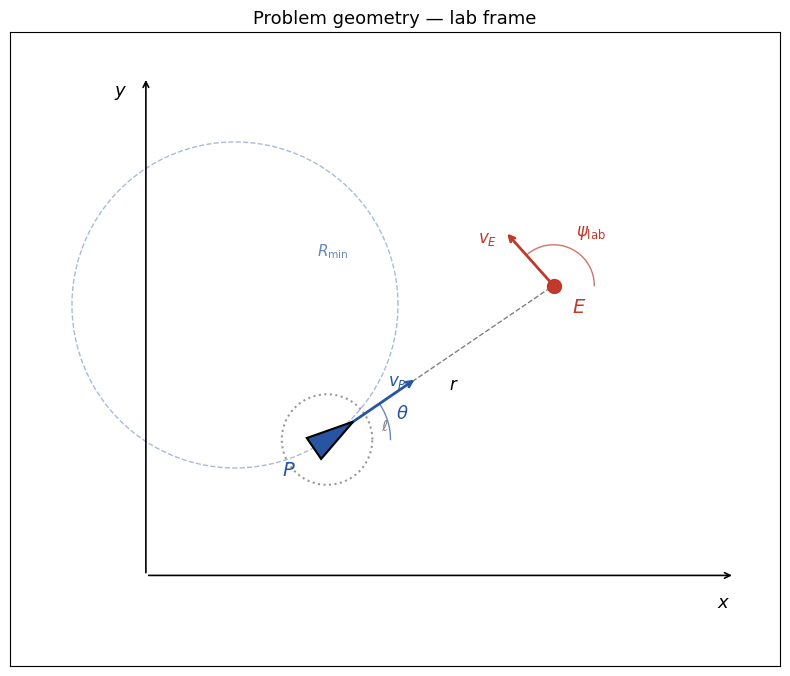

In [9]:
# §5 supporting figure — lab-frame schematic (problem geometry).
# Sets up the 5-DOF lab state (P_lab, E_lab, θ) the body-frame
# reduction below will collapse to 2 DOF.
from plots import problem_geometry
problem_geometry()


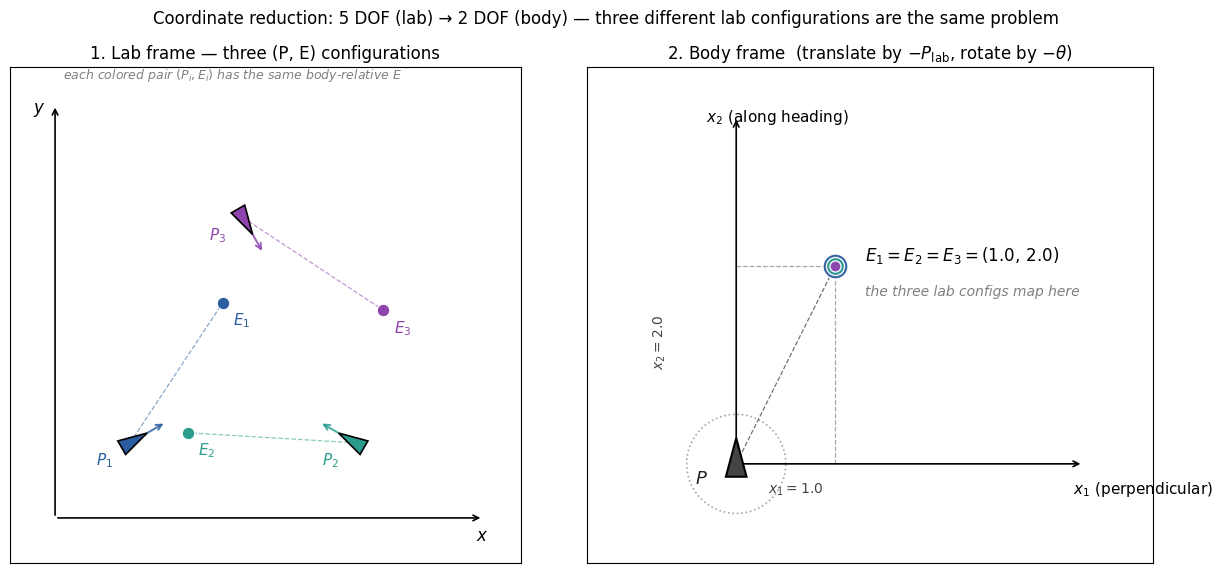

In [10]:
# §5 figure — three lab configurations collapse to ONE body-frame point.
# Makes the dimensional-reduction insight visible: the body frame is an
# equivalence class on the 5-DOF lab state, not just a relabelling.
from plots import coordinate_progression
coordinate_progression()


## Defining $V^*$ and constructing the Hamiltonian

The **value function** $V^*(\mathbf{x})$ is what we are after: the optimal capture time when the game starts from body state $\mathbf{x}$ with both players following the saddle-point strategy. The reachable set at time $T$ is its sublevel $R(T) = \{\, \mathbf{x} : V^*(\mathbf{x}) \leq T \,\}$ — the set of starting positions from which capture is possible within $T$ seconds of optimal play. $V^*$ exists everywhere the game is well-posed; §8 will render the whole field as a heat map. This section derives the differential equations that connect $V^*$ to the dynamics.

The plan is backward characteristics. The terminal condition is fixed — at the moment of capture, the state lies on the circle $x_1^2 + x_2^2 = \ell^2$ and $V^* = 0$. Optimal trajectories arrive at that boundary; integrating their dynamics backward in time from the boundary recovers $V^*(\mathbf{x})$ everywhere the characteristics reach. The Hamilton-Jacobi-Isaacs (HJI) PDE [@bardi1999pursuit] is the axiomatic-formal statement of this — $V^*$ is its viscosity solution — and §8 makes the anchor explicit; here we set up the characteristics by writing the Hamiltonian.


For the time-optimal differential game the Hamiltonian assembles directly: $H = p_1 f_1 + p_2 f_2 + 1$, where $p_1, p_2$ are the costate components dual to $(x_1, x_2)$ and the $+1$ comes from minimising the running cost $L = 1$ (capture time itself). One line of SymPy multiplication:


In [11]:
# §6 — Hamiltonian assembly: H = p_1 f_1 + p_2 f_2 + 1 (Pontryagin, L=1).
H = p1 * f1 + p2 * f2 + 1
sp.Eq(sp.Symbol("H"), H)


**Notice that $H$ is *linear* in the pursuer control $\phi$** — that is the structural observation the next cell exploits. One SymPy call (`sp.expand(H).coeff(phi)`) extracts the coefficient of $\phi$ — the **switching function** $\sigma = p_2 x_1 - p_1 x_2$ falls out directly:


In [12]:
# §6 — Switching function via one SymPy call: σ = sp.expand(H).coeff(φ).
sigma = sp.expand(H).coeff(phi)
sp.Eq(sp.Symbol(r"\sigma"), sigma)


PMP's bang-bang minimiser is then $\phi^* = -\mathrm{sign}(\sigma)$, because minimising a linear function over $[-1, 1]$ always lands on the boundary opposite the slope's sign [@merz1971, §3.2]. The locus $\sigma = 0$ is where the bang-bang control switches; in HC this locus is a curve in body space — the *dispersal surface* §7 visits.


In [13]:
# §6 — Bang-bang pursuer control: φ* = -sign(σ).
phi_star = -sp.sign(sigma)
sp.Eq(sp.Symbol(r"\phi^*"), phi_star)


The evader's optimal heading falls out the same way: $\psi^* = \mathrm{atan2}(p_1, p_2)$ maximises the evader's contribution to $H$, which works out to the evader pointing its velocity vector along the costate $\mathbf{p}$.

*Geometric reading: the costate is the gradient of the value function, and the evader runs straight up that gradient.* This is the single most useful intuition the rest of the paper trades on.


In [14]:
# §6 — Optimal evader heading: ψ* = atan2(p_1, p_2).
psi_star = sp.atan2(p1, p2)
sp.Eq(sp.Symbol(r"\psi^*"), psi_star)


One technical detail anchors §8's backward integration: the usable part of the terminal capture circle is the arc where $\sin \alpha > w$ [@merz1971, §4]; only on that arc can the pursuer prevent the evader from escaping at the moment of contact. Backward characteristics start from this arc, parameterised by $\alpha$. Section 8's `value_function_grid` sweeps $\alpha$ and integrates each characteristic backward to build the field.

Section 7 takes one optimal play through every coordinate lens at once. The cells we just built — Hamiltonian, switching function, bang-bang control, evader heading — are the analytical content the next figure visualises.


## One trajectory through every lens — the glass-box moment

Substituting `φ*` and `ψ*` into the body-frame dynamics gives a 4-dimensional autonomous ODE in `(x_1, x_2, p_1, p_2)`. The `798fab91` cell displays it: state evolves under the closed-loop dynamics with bang-bang `φ* = -sign(σ)` and the evader-velocity components determined by `p`. This 4-D system is the *axiomatic-formal object* the rest of §7 visualises — every figure below is a slice through one solution of this ODE.

The 6-panel `dispersal_crossing` figure (`be9a7a2b`; rendered via matplotlib) shows one optimal chase through six coordinate views simultaneously. The chase is the same one §3's `chase_demo` motivates; here it is decomposed into its analytical structure. We walk the panels:

**(1,1) Lab frame, pursuer highlighted.** The pursuer's trajectory traces an S-shape, with the bang-bang `φ*` jumping at the dispersal switch (★). The evader's path is greyed.

**(1,2) Strategy: σ(t).** The switching function plotted forward in time. The curve crosses zero exactly at the ★. The sign of `σ` colours the trajectory in (1,1) — warm for `σ > 0`, cool for `σ < 0`. The crossing *is* the seam: at `σ = 0` the pursuer's optimal turning direction is undetermined, and the trajectory bifurcates into two regimes the singular-surface analysis classifies as a *dispersal surface* [@merz1971; @bernhard1977].

**(1,3) State: body-frame trajectory.** The same chase in body coordinates `(x_1, x_2)`. The evader spirals inward toward the capture circle; the spiral pitch flips at the dispersal crossing. This panel is the equivalence-class representative of the lab-frame chases in (1,1) and (2,1).

**(2,1) Lab frame, evader highlighted.** Same chase, opposite highlight. The evader's path is the smooth-then-kinked curve we previewed in §3's `chase_demo`. The pursuer is greyed; the ★ is still there.

**(2,2) Strategy: ψ\*(t).** The evader's optimal heading, forward in time. Like `φ*`, `ψ*` jumps at the ★ — the heading-angle discontinuity is what produces the visible kink in the evader's lab-frame path.

**(2,3) Costate: (p_1, p_2) phase portrait.** The costate trajectory. Two concentric circles of radii `‖p‖_B` and `‖p‖_A` (different on either side of the dispersal) are connected by a dotted red chord at the switch — `V*`'s gradient is multi-valued at the dispersal surface, and the costate magnitude jumps pre- and post-switch.

The chase rendered across all six panels is recovered from `chase_demo`'s hardcoded arrays by stitching two optimal characteristics joined at the dispersal point — `α_A = 40°` post-switch, `α_B = 95°` pre-switch — so the chase in §3 and the analytical decomposition in §7 are the *same* chase. The plumbing lives in `plots._recover_chase_from_demo`; the costate norms differ across the switch (`‖p‖_B ≈ 1.83`, `‖p‖_A ≈ 5.18`), which is exactly what makes a dispersal surface a *seam* in strategy space.

**This is the glass-box moment.** Every panel of `dispersal_crossing` renders a slice of the *same* 4-D ODE solution. The seams between coordinate systems — lab ↔ body ↔ strategy ↔ costate — are now executable cells, not paragraph headers. The reader can re-run with different `(w, ℓ)`, re-stitch with different `(α_A, α_B)`, or call any of `derivations.py`, `numerics.py`, `plots.py` directly from a fresh notebook to inspect any intermediate object. If one optimal chase has structure this rich, what does the whole space of starts look like? Section 8 answers — and earns the §1 promise of *verifying the whole chain* via the costate ODE, conservation lemma, and lambdified RHS that the heat map sits on top of (with Appendix B running the live cross-check between the symbolic and numerical evidence).


In [15]:
# §7 — The 4-D characteristic ODE with φ*, ψ* substituted (the autonomous closed-loop system).
from derivations import characteristic_system
sp.Eq(
    sp.Matrix([
        sp.Symbol(r"\dot{x}_1"), sp.Symbol(r"\dot{x}_2"),
        sp.Symbol(r"\dot{p}_1"), sp.Symbol(r"\dot{p}_2"),
    ]),
    sp.Matrix(list(characteristic_system())),
)


             ⎡       p₁⋅w                                 ⎤
             ⎢  ────────────── + x₂⋅sign(-p₁⋅x₂ + p₂⋅x₁)  ⎥
             ⎢     ___________                            ⎥
             ⎢    ╱   2     2                             ⎥
⎡\dot{x}₁⎤   ⎢  ╲╱  p₁  + p₂                              ⎥
⎢        ⎥   ⎢                                            ⎥
⎢\dot{x}₂⎥   ⎢     p₂⋅w                                   ⎥
⎢        ⎥ = ⎢────────────── - x₁⋅sign(-p₁⋅x₂ + p₂⋅x₁) - 1⎥
⎢\dot{p}₁⎥   ⎢   ___________                              ⎥
⎢        ⎥   ⎢  ╱   2     2                               ⎥
⎣\dot{p}₂⎦   ⎢╲╱  p₁  + p₂                                ⎥
             ⎢                                            ⎥
             ⎢          p₂⋅sign(-p₁⋅x₂ + p₂⋅x₁)           ⎥
             ⎢                                            ⎥
             ⎣          -p₁⋅sign(-p₁⋅x₂ + p₂⋅x₁)          ⎦

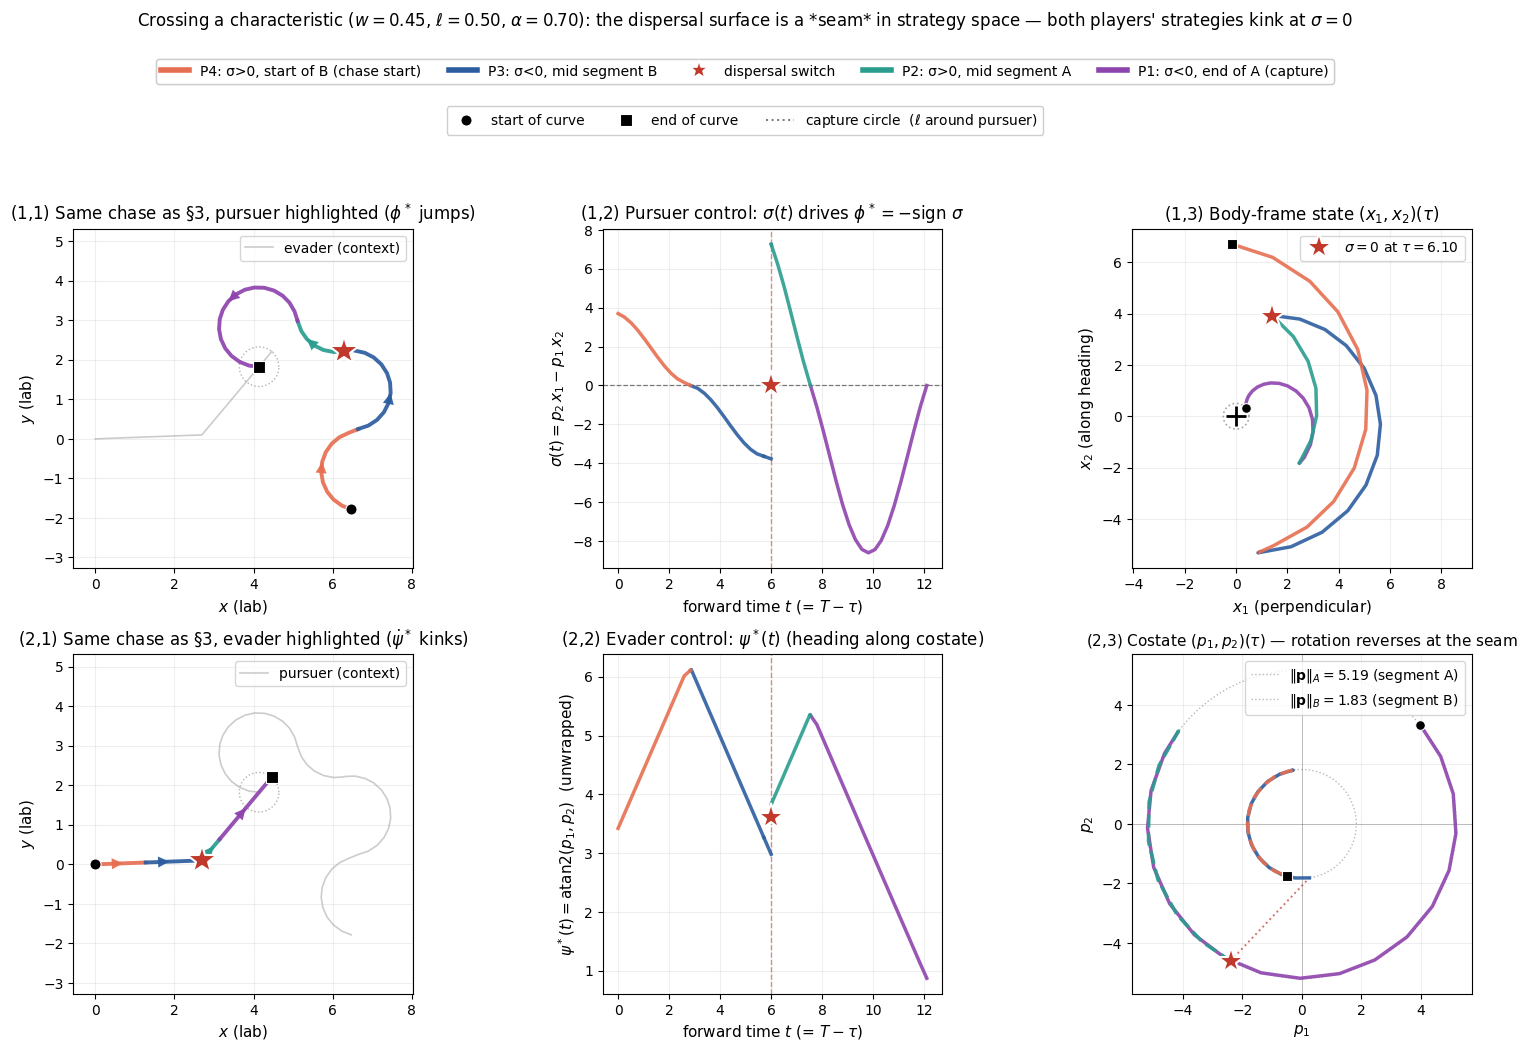

In [16]:
# §7 GLASS-BOX EXEMPLAR — one optimal play, six coordinate views.
# Panel layout + reading guide in the preceding §7 prose.
from plots import dispersal_crossing
dispersal_crossing()


## The value function as backward reachable set — the synthesis

Section 8 has two jobs: render $V^*(x_1, x_2)$ over the body frame as a heat map, and finish the analytical machinery — costate ODE, conservation invariant, and the SymPy → NumPy seam — that the heat-map cell depends on. We do the machinery first, then render the synthesis figure, then walk the figure.


The **costate (adjoint) ODE** is Pontryagin's adjoint written symbolically: $\dot{p}_i = -\partial H / \partial x_i$. Two `sp.diff` calls:


In [17]:
# §8 — Costate (adjoint) ODE for p_1: dp_1/dt = -∂H/∂x_1.
# Pontryagin's maximum principle, written as a one-line SymPy call.
sp.Eq(sp.Symbol(r"\dot{p}_1"), -sp.diff(H, x1))


In [18]:
# §8 — Costate ODE for p_2: dp_2/dt = -∂H/∂x_2.
sp.Eq(sp.Symbol(r"\dot{p}_2"), -sp.diff(H, x2))


With the adjoint dynamics in hand, we sweep 600 backward characteristics from the usable terminal arc, integrate each one back to $\tau = 15$ s, and interpolate the $(x_1, x_2, \tau)$ samples onto a 180 × 180 grid. Plasma colour codes capture time from 0 (purple, on the capture circle) to 15 s (yellow at the cap). The pursuer triangle sits at the origin with heading $+x_2$; white isochrones at $T = 2, 6, 12$ trace level sets of $V^*$.

The black diamond is the §3 `chase_demo` initial condition, mapped through the body-frame substitution to $(-0.166, 6.708)$. The legend's $V^*(\diamond) \approx 12.1$ s is plumbed in directly from `chase_demo`'s measured saddle-point capture time — the heat map's smoothed interpolation would *over-report* because the backward angular fan does not land exactly on this IC. Same chase, two sections, one number.

The **15-second cap is a *rendering* horizon, not a game-theoretic claim**. For $w = 0.45 < 1$ the pursuer eventually catches from any IC; cells the angular fan does not reach within 15 seconds render in dark grey. Genuinely no-capture regimes — where the evader escapes indefinitely via stable limit cycles around the pursuer's turning circle — require $w > 1$ or specific singular-surface geometries [@merz1971; @bardi1999pursuit, §3].

The sharp boundary where the dark inner kidney meets the lighter outer field is the *barrier singular surface* — $V^*$'s level sets meet at a corner there, with $V^*$ jumping from ~2 s to ~6 s over less than 0.5 body-frame units. Sampling-density checks (`n_traj ∈ {100, 300, 600}`) confirm it as a real HC feature, not a sampling artefact.


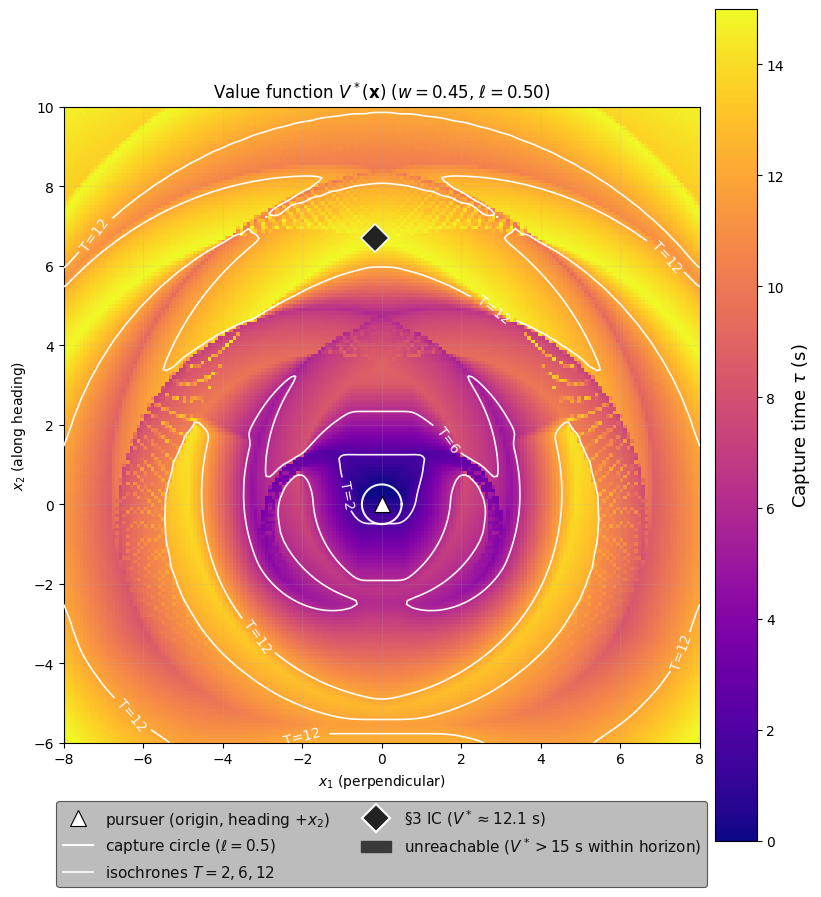

In [19]:
# §8 SYNTHESIS — V*(x) on a body-frame grid; see §8 prose for the
# 15-s cap, IC anchor, and barrier-surface interpretations.
# (Bump _VFG_CACHE_VERSION in numerics.py to invalidate the .npz cache.)
from numerics import value_function_grid
from plots import reachable_set_heatmap

W_REF, ELL_REF = 0.45, 0.5
ISOCHRONE_LEVELS = (2.0, 6.0, 12.0)

x1_grid, x2_grid, V_grid, reachable_mask, isochrones = value_function_grid(
    W_REF, ELL_REF,
    T_max_cap=15.0,
    grid_extent=(-8.0, 8.0, -6.0, 10.0),
    n_grid=180,
    n_traj=600,
    n_time_samples=400,
    isochrone_levels=ISOCHRONE_LEVELS,
)
reachable_set_heatmap(
    x1_grid, x2_grid, V_grid, reachable_mask, W_REF, ELL_REF,
    T_max_cap=15.0, vmax_color=15.0,
    isochrone_levels=ISOCHRONE_LEVELS,
    isochrone_curves=isochrones,
    highlight_ic=(-0.166, 6.708, "§3 IC"),
    highlight_ic_value=12.1,
)


Two more cells finish the analytical machinery the heat map sits on top of. The **conservation lemma** shows that $d/dt\|\mathbf{p}\|^2 = 0$ along every optimal characteristic. The chain-rule sum is held un-evaluated with `sp.Add(..., evaluate=False)` so SymPy's auto-simplifier doesn't collapse it before the reader sees the structure; the next cell's `sp.simplify` is what actually drives the result to literal zero:


In [20]:
# §8 — Conservation lemma 1: chain-rule sum, kept unevaluated
# (sp.Add(..., evaluate=False)) so sp.simplify drives the cancellation in lemma 2.
p1_dot = -sp.diff(H, x1)
p2_dot = -sp.diff(H, x2)
drift_raw = sp.Add(2 * p1 * p1_dot, 2 * p2 * p2_dot, evaluate=False)
sp.Eq(sp.Symbol(r"\tfrac{d}{dt}\|\mathbf{p}\|^2_{\,\text{raw}}"), drift_raw)


\tfrac{d}{dt}\|\mathbf{p}\|_{\,\text{raw}}__2 = -2⋅p₁⋅p₂⋅φ + 2⋅p₁⋅p₂⋅φ

In [21]:
# §8 — Conservation lemma 2: sp.simplify drives the drift to literal zero.
drift = sp.simplify(drift_raw)
sp.Eq(sp.Symbol(r"\tfrac{d}{dt}\|\mathbf{p}\|^2"), drift)


\tfrac{d}{dt}\|\mathbf{p}\|² = 0

**Watch this:** SymPy did in one line the cancellation Isaacs (1965) verified by hand. The conservation invariant is now executable evidence rather than a textbook claim.

**The seam.** `numerics.lambdify_rhs` calls `sp.lambdify` on the characteristic ODE system, returning a NumPy-callable `rhs(t, state, w)` where `state = [x_1, x_2, p_1, p_2]` and the return value is the 4-vector $[\dot{x}_1, \dot{x}_2, \dot{p}_1, \dot{p}_2]$. This is exactly the signature `scipy.integrate.solve_ivp` consumes when integrating the 600 backward characteristics for the heat map. White-box on the symbolic side (the SymPy expression is inspectable with `sp.srepr`), black-box on the numeric side (a fast callable for the integrator), glass-box because both sides live in the source [@meurer2017sympy; @virtanen2020scipy].

To make the seam concrete: at probe state $(x_1, x_2, p_1, p_2) = (1.0, 0.5, 0.3, 0.8)$ with $w = 0.3$, the closed-form derivations give $\sigma = p_2 x_1 - p_1 x_2 = 0.65 > 0$, so $\phi^* = -1$. Then $\dot{x}_1 = -\phi^* x_2 + w \sin \psi^* \approx 0.605$, $\dot{x}_2 = \phi^* x_1 + w \cos \psi^* - 1 \approx -1.719$, $\dot{p}_1 = -p_2 \phi^* = 0.8$, $\dot{p}_2 = p_1 \phi^* = -0.3$. The lambdified callable returns the same four numbers:


In [22]:
# §8 — THE SEAM: SymPy → NumPy via sp.lambdify. Probe-state spot-check.
# Closed-form expected values: see §8 prose immediately above.
from numerics import lambdify_rhs
rhs = lambdify_rhs()
rhs(0.0, [1.0, 0.5, 0.3, 0.8], 0.3)


One sentence anchors $V^*$ to its axiomatic-formal definition: it is the unique viscosity solution of the Hamilton-Jacobi-Isaacs PDE with $V = 0$ on the capture circle [@bardi1999pursuit]. We render $V^*$ via backward characteristics rather than by solving the PDE because shipping a viscosity-solution finite-element solver in 6,000 words is beyond scope — the axiomatic-formal anchor is the PDE itself, cited rather than enacted. Two further figures (`plots.optimal_vector_field` for the bang-bang feedback policy, `plots.trajectory_fan` for the family of optimal characteristics) live in the codebase and ship with the public hc-marimo notebook [@zargham2026hcmarimo; @harris2020numpy; @hunter2007matplotlib].


## What just happened: SymPy is the missing world; the SciPy stack now covers all three

Standard SciPy practice covers two of Tall's three worlds. NumPy and SciPy operationalise the **operational-symbolic** world: procedures that solve, integrate, optimise [@harris2020numpy; @virtanen2020scipy]. Matplotlib operationalises the **conceptual-embodied** world: vector fields, trajectories, heat maps you read with your eyes [@hunter2007matplotlib]. The **axiomatic-formal** world — symbol-as-object manipulation under rewrite rules — usually lives on paper or in a textbook citation. SymPy [@meurer2017sympy] is what moves it into the same execution environment.

What changed in this paper because SymPy was in the notebook? The body-frame reduction in §5 ran as a SymPy chain (`sp.diff` + `sp.subs` + `sp.trigsimp`) rather than three pages of indices. The Hamiltonian in §6 assembled in a single line, $H = p_1 f_1 + p_2 f_2 + 1$. The switching function fell out as `sp.expand(H).coeff(phi)` instead of by-hand collection of terms. The costate ODE was a `sp.diff(H, x_i)` call; the conservation lemma a `sp.simplify(...)` that returned literal zero. Without SymPy, the axiomatic-formal content of those sections would be "see Isaacs (1965) pp. 297-320 for the derivation" and the reader's only audit path would be to read Isaacs. With SymPy, the reader watches the derivation happen and can re-run any cell with different parameters to verify the chain end-to-end.

The Buchberger principle [@buchberger1990] governs which mode of work belongs where. Differentiation and integration *rules* belong in the black-box mode by now — they have been in their white-box phase since Heid [@heid1988]'s 1988 calculator-classroom studies, and we trust `sp.diff` to apply them. The white-box mode in this paper is therefore *one rung up the recursion*: Hamiltonian construction, costate derivation, switching-function recognition. Drijvers and Artigue [@artigue2002; @tall1991amtcomputer] sharpened Buchberger's binary into a third mode — *glass-box*, where the tool is transparent in *derivation* even if the user did not perform every algebraic step by hand. SymPy is glass-box in this sense: `sp.expand(H).coeff(phi)` is a single call, but the reader can inspect $H$ before and after, ask for `H.atoms()` or `H.free_symbols`, and trace exactly which rule was applied.


One cell in this section illustrates the *limits* of what computer algebra automates. Substituting $\phi^* = -\mathrm{sign}(\sigma)$ into $H$ — and SymPy returns a `Piecewise` expression branching on the sign of $\sigma$. The auto-simplifier does not reduce $-\mathrm{sign}(\sigma) \cdot \sigma$ to $-|\sigma|$ because the recognition step needs a pattern rewrite SymPy does not apply by default. An honest moment: glass-box does not mean *omniscient*, it means *inspectable*.


In [23]:
# §9 — Live H.subs(φ, φ*). SymPy returns Piecewise — the auto-simplifier
# does not auto-reduce -sign(σ)·σ to -|σ|. See §9 prose for the honest moment.
H_after_phi = H.subs(phi, phi_star)
H_after_phi


The clean closed form, written by Isaacs (1965, p. 304) as $H^* = w\|\mathbf{p}\| - |\sigma| - p_2 + 1$, is the saddle-point Hamiltonian the bang-bang substitution *should* reduce to. A one-line `sp.simplify(H_after_phi - H_star_clean)` would verify the equivalence for the reader who wants to audit by hand; we display the clean form here directly via the helper in `derivations.py`:


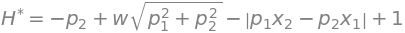

In [24]:
# §9 — Closed-form H* (Isaacs 1965, p. 304), via derivations.hamiltonian_saddle().
from derivations import hamiltonian_saddle
sp.Eq(sp.Symbol(r"H^*"), hamiltonian_saddle())


Sections 5 through 8 are what earn the §1 thesis: **the glass-box principle becomes practicable when all three of Tall's worlds live in the same execution environment.** §1 stated the claim prospectively; the body grounds it. Standard SciPy practice already keeps the operational-symbolic and embodied worlds in the same notebook; SymPy bridges the axiomatic-formal world onto the same page as the figures it justifies. The seams between worlds — `derivations.py` → `numerics.lambdify_rhs` → `scipy.integrate.solve_ivp` → `matplotlib.Figure` — are what the reader can audit. Without SymPy, the chain has one black-box step (the formal derivation in a citation); with SymPy, every step is glass-box. Section 10 names the publication infrastructure that makes all three worlds live in one artifact.


## Conclusion: critical infrastructure + reproducibility + methodology generalises

We named four tool families to make this paper work — SymPy for the axiomatic-formal world, NumPy and SciPy for operational-symbolic, matplotlib for embodied, and MyST + Jupyter + Curvenote for the integrating substrate. We credit them all together because the contribution is about the *category* of tools they exemplify, not about any specific stack. A dynamic computational-publication environment combines text, parameters, symbolic derivations, numerical simulations, and visual elements *in the same artifact*; this paper is one instance of the category, and the public hc-marimo notebook this paper is built on [@zargham2026hcmarimo], running on the marimo framework [@agrawal2023marimo], is another. The two instances run on different infrastructure (marimo + GitHub Pages versus Jupyter + MyST + Curvenote [@jupyterbook2025; @kluyver2016jupyter]) and the choice between them is engineering taste — the load-bearing claim is the category itself. Kadie's 2025 SciPy paper on solvable and unsolvable equations in SymPy [@kadie2025solvable] is another notebook-primary instance in the same proceedings — the architectural choice is no longer unprecedented.

**The methodology generalises.** The same treatment — symbolic derivation in SymPy, numerical integration in SciPy, visual decomposition in matplotlib, with the seams visible — applies to other control-systems concepts where the formalism is hard to materialise and the embodied view is load-bearing. Three named instances live at hc-marimo: (1) the singular-surface taxonomy applied to autonomous-vehicle (AV) collision avoidance, where dispersal and equivocal surfaces classify decision boundaries [@bernhard1977; @merz1971]; (2) multi-pursuer differential games applied to unmanned-aerial-vehicle (UAV) swarm defense, where coalition value functions extend Isaacs's pursuit framework [@kumkov2017multipursuer]; (3) forward physical-coordinate chase applied to hardware-in-the-loop (HIL) testing of pursuit controllers — the same characteristic-integration backbone (built from the modern HC restatement [@pachter2019hc]) drives controller validation in a simulator. Each lives at hc-marimo alongside the figures cut from this paper for space (`plots.optimal_vector_field` for the bang-bang feedback view; `plots.trajectory_fan` for the family of optimal characteristics; `plots.conservation_diagnostics` for the numerical-invariant drift plots).

**Personal motivation.** We have found Tall's three-worlds model, the glass-box principle, and reactive notebooks indispensable communication aids for advanced engineering mathematics across several artefacts at the Dynamical Systems Group — the public hc-marimo notebook this paper is built on, the ADCS-lifecycle requirements-traceability demo [@zargham2026adcs], and the GDS-Axelrod evolution-of-trust showcase [@mehta2025gdsaxelrod]. The same three-worlds pedagogy extends to settings where the state space is a data structure rather than a real-valued field and differentiability cannot be assumed [@zargham2022generalized; @zargham2026protocols]; the symbolic substrate need not be SymPy — semantic-web tools such as the Web Ontology Language (OWL) [@w3c2012owl2] also provide formal inference.

**Sharpened pitch.** The embodied and interactive modes are particularly load-bearing at the graduate level, where the formalism is hardest to materialise on the page. The axiomatic-formal world being *operationally available* via SymPy — not hand-waved through "see the textbook" — unlocks pedagogical ground that pure-numerical SciPy practice cannot reach. Glass-box is the practical mode for that ground: the reader audits the symbolic derivation, watches the lambdified function get integrated, reads the resulting figure, and can ground-truth any step against the next.

**Reproducibility.** The suite under `tests/` runs in about 5 seconds via `uv run pytest tests/` and certifies every body-section invariant the paper relies on. **Appendix B** carries the full audit: the per-test catalog, a live pytest run executed in-notebook, and the symbolic-vs-numerical cross-check on the costate-norm conservation lemma — the same `d/dt‖p‖² = 0` that §8 proves by `sp.simplify` is verified numerically to the integrator's noise floor along every characteristic. The audit exists so this section can name "the math holds" once and let the appendix carry the evidence.

The publication substrate makes the integration possible. Crediting the SymPy, NumPy, SciPy, matplotlib, Jupyter, MyST, Curvenote, and marimo teams is therefore not a courtesy line; it is the load-bearing acknowledgement that scientific computing now has the infrastructure to operationalise Tall's three-worlds theory in a single executable artifact. Teaching advanced applied mathematics finally has the substrate it always needed.


## Appendix A — Notation reference {.unnumbered}

Every symbol the paper uses, grouped by role. Cross-referenced from the §4 notation quickstart.

| Term | Notation | Short description |
|---|---|---|
| **Lab frame** | | |
| Pursuer / evader positions | $x_P, y_P, x_E, y_E$ | Cartesian lab-frame coordinates of each player |
| Pursuer lab heading | $\theta$ | Direction of $v_P$ in the lab; $\dot\theta = \phi$ |
| Evader lab heading | $\psi_{\mathrm{lab}}$ | Direction of $v_E$ in the lab; related to body heading by $\psi = \psi_{\mathrm{lab}} - \theta$ |
| Minimum turning radius | $R_{\min} = 1$ | Normalised to 1; reciprocal of the pursuer's max turn rate |
| Pursuer / evader speeds | $v_P = 1,\ v_E = w$ | Normalised so $v_P = 1$ |
| **State (body frame)** | | |
| Relative position, perpendicular to pursuer heading | $x_1$ | Component of $(\mathbf{E} - \mathbf{P})$ rotated into the pursuer's frame, perpendicular to heading |
| Relative position, along pursuer heading | $x_2$ | Component along the heading direction |
| **Costate / adjoint** | | |
| Adjoint variables | $p_1, p_2$ | Pontryagin's costate; equal the gradient $\nabla V^*$ of the value function |
| Costate magnitude | $\|\mathbf{p}\| = \sqrt{p_1^2 + p_2^2}$ | Conserved along every optimal characteristic (see §8) |
| **Controls** | | |
| Pursuer turn rate (bang-bang) | $\phi \in [-1, 1]$ | Normalised; $\|\phi\| \le 1$ is the minimum-turning-radius constraint |
| Evader heading (body frame) | $\psi$ | Lab-frame heading minus pursuer's $\theta$ |
| Optimal pursuer control | $\phi^* = -\operatorname{sign}(\sigma)$ | Bang-bang law from $H$ being linear in $\phi$ |
| Optimal evader heading | $\psi^* = \operatorname{atan2}(p_1, p_2)$ | Evader points velocity along the costate direction |
| **Parameters** | | |
| Evader-to-pursuer speed ratio | $w = v_E / v_P \in (0, 1)$ | The pursuer is always faster in this paper's regime |
| Capture radius | $\ell$ | Capture occurs when $\|\mathbf{P} - \mathbf{E}\| \le \ell$ |
| **Time** | | |
| Forward (physical) time | $t \in [0, T]$ | Wall-clock from chase start ($t=0$) to capture ($t=T$) |
| Backward time (time-to-go) | $\tau = T - t$ | The natural integration variable; $\tau = 0$ at capture |
| **Body-frame dynamics** | | |
| RHS of the reduced ODE | $f_1, f_2$ | $\dot{x}_1 = f_1$, $\dot{x}_2 = f_2$ — defined in §5 |
| **Game-theoretic objects** | | |
| Hamiltonian | $H = p_1 f_1 + p_2 f_2 + 1$ | $+1$ is the running cost for time-optimal capture |
| Switching function | $\sigma = p_2 x_1 - p_1 x_2$ | Coefficient of $\phi$ in $H$; its sign determines $\phi^*$ |
| Saddle-point Hamiltonian | $H^* = w\|\mathbf{p}\| - \|\sigma\| - p_2 + 1$ | $H$ with $\phi^*$ and $\psi^*$ substituted (Isaacs 1965, p. 304) |
| Value function | $V^*(\mathbf{x})$ | Optimal capture time starting from body state $\mathbf{x}$ |
| Reachable set at time $T$ | $\mathcal{R}(T) = \{\mathbf{x} : V^*(\mathbf{x}) \le T\}$ | Initial conditions captured within $T$ — visualised in §8 |
| Terminal capture circle | $\partial \mathcal{R}(0) = \{\mathbf{x} : \|\mathbf{x}\| = \ell\}$ | Body-frame boundary backward integration starts from |
| **Singular surfaces** | | |
| Dispersal surface | $\{\sigma = 0\}$ | Locus where $\phi^*$ flips sign; chase_demo crosses this at the ★ |


## Appendix B — Verification audit {.unnumbered}

The body of the paper highlights two invariants — `d/dt‖p‖² = 0` from
the symbolic `sp.simplify` lemma chain, and `H* ≈ 0` along integrated
trajectories — as the formal-correctness evidence for the saddle-point
construction. This appendix carries the **full** verification story so
the body can name the two highlights and move on.

Tests are how this paper makes Tall's *axiomatic-formal* world (`derivations.py`
identities) and *operational-symbolic* world (`numerics.py` invariants along
integrated trajectories) physically auditable in CI. The third Tall world —
*conceptual-embodied* — is audited differently: every figure requires human
visual inspection. The smoke tests in `test_plots.py` check that each figure *renders*
without erroring in a headless backend — they verify reproducibility (the
figure regenerates) without verifying *correctness* (the figure shows what
the prose says it shows). Reading the figure for correctness is part of
the audit, and it is the reader's job. Appendix A names the visual vocabulary the reader
applies; this appendix lists the automated coverage that surrounds it.

Every test file pairs with one module: `test_derivations.py` checks symbolic
identities, `test_numerics.py` checks numerical invariants, `test_plots.py`
runs the figure smoke checks, `test_utils.py` checks citation hygiene. The
suite is small (35 tests) and fast (≈ 5 s) by design — reviewers should be
able to read the failure of any one test as a localised disagreement with a
specific source citation.

The reviewer recipe in `README.md` is one line: `uv run pytest tests/`.
The cells below run the same command in-process and print the report,
then list which body section each test backs. The final cell juxtaposes
the symbolic and numerical proofs of the costate-norm conservation law —
the same axiomatic-formal claim verified twice in two different
operational regimes, with the embodied verification (the heat-map figure
in §8) carried by the reader's eye.


In [25]:
# Appendix B.2 — Test catalog grouped by module.
# Each entry: (test name, invariant verified, body §-anchor).
TEST_CATALOG = {
    "test_derivations.py": [
        ("test_R1_reduced_dynamics",
         "f_1, f_2 match Isaacs (1965) pp. 297-300",                       "§5"),
        ("test_R2_hamiltonian_linearity",
         "H linear in φ ⇒ switching-function structure",                   "§6"),
        ("test_R3_switching_function",
         "σ = expand(H).coeff(φ) = p_2 x_1 − p_1 x_2",                     "§6"),
        ("test_R4_optimal_psi",
         "ψ* = atan2(p_1, p_2); sin/cos substitutions",                    "§6"),
        ("test_R5_costate_conservation",
         "‖p‖² conserved symbolically — same as B.4 lemma",                "§8"),
        ("test_R6_separability",
         "Hamiltonian separates additively into (φ, ψ) blocks",            "§6"),
    ],
    "test_numerics.py": [
        ("test_T1_lambdify_consistency",
         "lambdified RHS matches hand-coded reference (random points)",    "§8 seam"),
        ("test_T2_hamiltonian_conservation",
         "H* ≈ 0 along integrated backward trajectories",                  "§8"),
        ("test_T3_costate_norm_conservation",
         "‖p‖²(t) conserved within rtol along trajectories — see B.4",     "§8"),
        ("test_T4_capture_condition",
         "terminal states lie on the capture circle",                      "§5/§6"),
        ("test_T6_stationary_evader",
         "w=0 collapses to straight-line capture",                         "§3 hook"),
        ("test_T7_usable_part",
         "usable terminal arc = { α : sin α > w }",                        "§6"),
        ("test_T8_trajectory_dense_output",
         "OdeResult objects expose .sol (continuous interpolant)",         "§7"),
        ("test_T9_value_function_field_isochrone_alignment",
         "isochrone endpoints satisfy V(x) ≤ T + ε",                       "§8"),
        ("test_T10_sample_trajectories_truncation",
         "sampler handles τ < traj.t[-1] and τ > traj.t[-1] cleanly",      "§7 widget"),
        ("test_T11_pure_pursuit_capture_detected",
         "pure-pursuit simulator's capture-detection event fires",         "§3 hook"),
        ("test_T12_pure_pursuit_perpendicular_outlasts_naive",
         "perpendicular evader survives longer than run-away — saddle-point bound", "§3 hook"),
        ("test_T13_value_function_grid_basic",
         "5-tuple shape; T_max_cap honoured; isochrones nonempty",         "§8"),
        ("test_T14_value_function_grid_cache_roundtrip",
         "SHA-256-keyed .npz cache: cold write, warm read identical",      "§8 (caching)"),
        ("test_T15_barrier_persists_across_sampling_densities",
         "barrier surface area stable across n_traj ∈ {100, 300, 600}",   "§8 barrier"),
    ],
    "test_plots.py": [
        ("test_chase_demo_returns_figure",                "1-axis chase render",       "§3"),
        ("test_problem_geometry_returns_figure",          "lab-frame schematic",       "§5"),
        ("test_coordinate_progression_two_panels",        "5-DOF→2-DOF collapse",      "§5"),
        ("test_dispersal_crossing_six_panels",            "6-axis glass-box exemplar", "§7"),
        ("test_optimal_vector_field_returns_figure",      "quiver of optimal velocity (kept in module)", "(hc-marimo)"),
        ("test_trajectory_fan_returns_figure",            "fan of characteristics (kept in module)",     "(hc-marimo)"),
        ("test_trajectory_frame_returns_figure",          "single-τ animation frame (kept in module)",   "(hc-marimo)"),
        ("test_reachable_set_view_returns_figure",        "scatter+isochrones V*(x) (kept in module)",   "(hc-marimo)"),
        ("test_conservation_diagnostics_returns_two_axes","H* + ‖p‖² drift (kept in module)",            "(hc-marimo)"),
        ("test_naive_vs_optimal_returns_figure",          "§3 hook 2-panel",            "§3"),
        ("test_reachable_set_heatmap_returns_figure",     "§8 primary figure",          "§8"),
    ],
    "test_utils.py": [
        ("test_validate_citations_pass",       "no orphans + no missing in a known-good bib", "infra"),
        ("test_validate_citations_orphan",     "orphan detection fires on synthetic input",   "infra"),
        ("test_validate_citations_missing",    "missing-key detection fires",                 "infra"),
        ("test_bib_to_yaml_roundtrip",         "bib → yaml → re-parse preserves keys",        "infra"),
    ],
}

# Pretty-print summary
total = 0
for module, tests in TEST_CATALOG.items():
    print(f"\n{module}  ({len(tests)} tests)")
    print("-" * (len(module) + len(f"  ({len(tests)} tests)")))
    for name, invariant, anchor in tests:
        print(f"  {name:55s} [{anchor:>14s}]  {invariant}")
    total += len(tests)
print(f"\nTotal: {total} tests across {len(TEST_CATALOG)} modules.")



test_derivations.py  (6 tests)
------------------------------
  test_R1_reduced_dynamics                                [            §5]  f_1, f_2 match Isaacs (1965) pp. 297-300
  test_R2_hamiltonian_linearity                           [            §6]  H linear in φ ⇒ switching-function structure
  test_R3_switching_function                              [            §6]  σ = expand(H).coeff(φ) = p_2 x_1 − p_1 x_2
  test_R4_optimal_psi                                     [            §6]  ψ* = atan2(p_1, p_2); sin/cos substitutions
  test_R5_costate_conservation                            [            §8]  ‖p‖² conserved symbolically — same as B.4 lemma
  test_R6_separability                                    [            §6]  Hamiltonian separates additively into (φ, ψ) blocks

test_numerics.py  (14 tests)
----------------------------
  test_T1_lambdify_consistency                            [       §8 seam]  lambdified RHS matches hand-coded reference (random points)
  test_T2_ham

In [26]:
# Appendix B.3 — Live test execution.
# Run pytest in a subprocess so its 35-line PASSED report renders as
# ONE captured output block in the PDF (in-process pytest.main with -v
# emits each PASSED as its own stream output, which the typst template
# renders as a separate code-block with vertical spacing — 7 pages of
# bloat at the published page width). Subprocess capture collapses
# them to one compact block. Same invocation as the README's reviewer
# recipe `uv run pytest tests/`.
import subprocess
result = subprocess.run(
    ["uv", "run", "pytest", "tests/", "--tb=short", "--no-header", "-q"],
    capture_output=True, text=True, cwd=".",
)
print(result.stdout)
if result.returncode != 0:
    print("--- STDERR ---")
    print(result.stderr)
assert result.returncode == 0, f"Test suite failed (exit {result.returncode})"


============================= test session starts ==============================
collected 35 items

tests/test_derivations.py ......                                         [ 17%]
tests/test_numerics.py ..............                                    [ 57%]
tests/test_plots.py ...........                                          [ 88%]
tests/test_utils.py ....                                                 [100%]

============================= 35 passed in 21.07s ==============================



**The conservation invariant in two worlds (and the third by inspection).**
The §8 SymPy lemma chain shows `d/dt‖p‖² = 0` symbolically — `sp.simplify`
drives the algebraic cancellation to literal zero. The same axiomatic-formal
claim is also a numerical invariant of every integrated trajectory:
`test_T3_costate_norm_conservation` measures `‖p‖²(t)` along several backward
characteristics and asserts the relative drift stays at the integrator's
noise floor. Two of Tall's three worlds, two automated checks of the same
claim. The third — the conceptual-embodied verification — is the §8 heat map
itself: a reader inspecting the smooth, closed isochrones at `T = 2, 6, 12`
*sees* a well-behaved value function with no numerical artefacts, which is
the embodied audit of the same conservation property. Human review is the
test for that world; the cells below carry the other two.

The cell that follows runs the numerical check live and reports the
worst-case drift across a small trajectory bundle, so the reader can
*see* the integrator approximating the symbolic zero.


In [27]:
# Appendix B.4 — numerical evidence for the symbolic conservation lemma.
import numpy as np  # noqa: PLC0415
from numerics import compute_optimal_trajectories  # noqa: PLC0415

trajs = compute_optimal_trajectories(
    n_traj=12, T_horizon=8.0, w=0.45, ell=0.5,
)
worst_rel_drift = 0.0
for sol in trajs:
    if not sol.success:
        continue
    _, _, p1_t, p2_t = sol.y
    norm_sq = p1_t ** 2 + p2_t ** 2
    initial = float(norm_sq[0])
    if initial < 1e-12:
        continue
    rel_drift = float(np.max(np.abs(norm_sq - initial) / initial))
    worst_rel_drift = max(worst_rel_drift, rel_drift)

print(f"Symbolic claim (§8 sp.simplify):   d/dt‖p‖² = 0  (exact)")
print(f"Numerical worst-case rel. drift:   {worst_rel_drift:.2e}")
print(f"Integrator tolerance (rtol):       1e-10")
print(f"Verdict:                           drift sits at the integrator")
print(f"                                   noise floor — symbolic")
print(f"                                   invariant holds numerically.")


Symbolic claim (§8 sp.simplify):   d/dt‖p‖² = 0  (exact)
Numerical worst-case rel. drift:   2.22e-10
Integrator tolerance (rtol):       1e-10
Verdict:                           drift sits at the integrator
                                   noise floor — symbolic
                                   invariant holds numerically.


## Acknowledgments {.unnumbered}

Tools used: Claude Code (Anthropic), `claude-opus-4-7` (1M context window). The author specified this paper as point-for-point outlines, named all software components with test-driven development up front, and hand-tuned the code, figures, and text throughout the published content. The build order was outline → code → detailed outline → prose. AI assistance produced drafts inside that specification; the author corrected each pass and verified the mathematics against the cited primary sources [@isaacs1965; @merz1971; @pachter2019hc; @bardi1999pursuit]. The work was conducted in a variation of the purpose-built AI-assisted-authorship harness described and peer-reviewed in [@zargham2026incose], whose deterministic test gates — here, 35 pytest assertions and `utils.validate_citations` — and named-human approver field are the verification mechanism this paper inherits. The author takes full responsibility for the accuracy and integrity of the content.


## References {.unnumbered}

```{bibliography}
:filter: docname in docnames
```
